In [42]:
import os
import sys
from pathlib import Path

import numpy as np
import dabest
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append("../")
from src.io import read_parameters
from griottes import generate_delaunay_graph, plot_2D
from src.computation import build_velocity_dataset
import networkx as nx



cmap = matplotlib.colormaps["seismic_r"]

In [43]:
# read parameters and key file

parameter_file  = "/media/jpa/Volume/MDC/MDC_data/ec_tracking/trial/parameters_test_set.yml"
parameters = read_parameters(parameter_file)       

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)

print("key file columns:", key_file.columns)
print("key file conditions:", key_file["condition"].unique())

key file columns: Index(['experimentID', 'filename', 'color', 'treatment_old', 'treatment',
       'condition', 'frame_per_hour', 'date'],
      dtype='object')
key file conditions: ['Flow-siRNA' 'Stat-siRNA']


In [44]:
# create output folder

output_folder = Path(parameters["output_folder"])
print("Output folder:", output_folder)

data_folder = output_folder.joinpath("tracking_data")

subfolder = "time_graph_analysis"
if not os.path.exists(output_folder.joinpath(subfolder)):
    os.mkdir(output_folder.joinpath(subfolder))


Output folder: /media/jpa/Volume/MDC/MDC_data/ec_tracking/trial/out


In [45]:
# plot paramters

#condition = 'mosaic_siCTRL_siAlk1'
#condition = 'mosaic_siCTRL_siSMAD4'
# color = 'red'
#treatment = 'siAlk1'

#number_of_tracks_per_condition = 1000

observation_time = parameters["observation_time"]

# limits for min velocity and max velocity in um/h used for the color map
min_vel_lim = -20.0 # um/h
max_vel_lim = 20.0 # um/h

# extend in microns of the coordinate system used for plotting, 
# range is [-max_x, max_x] in x direction and [-max_y, max_y] in y direction
max_x = 600 # um
max_y = 600 # um

obs_time_length_frames = observation_time[1] - observation_time[0]

print("Observation time (frames):", observation_time)

plot_tracks = False
plot_arrows = True

distance_threshold = parameters.get("distance_threshold", 100) # um, default value if not specified in parameters

Observation time (frames): [0, 100]


In [46]:
num_subsample = 5

In [47]:

graphs = {}
observation_period_dfs = {}
# loop over all experiments of this condition
for experimentID in key_file["experimentID"].unique():
    print("Processing experiment:", experimentID)

    # can only be one entry
    key_exp = key_file[key_file["experimentID"] == experimentID]

    row = key_exp.iloc[0]
    treatment = row["treatment"]

    tracking_file = "tracking_data_%s_%s_%s.csv" % (treatment, row["color"], row["experimentID"])
    data = pd.read_csv(str(data_folder.joinpath(tracking_file)), low_memory=False)

    # filter data for observation period
    observation_period_df = data[data["FRAME"] <= observation_time[1]]
    observation_period_df = observation_period_df[observation_period_df["FRAME"] >= observation_time[0]]
    observation_period_dfs[experimentID] = observation_period_df

    # rename columns for G_delaunay graph generation
    observation_period_df_exp = observation_period_df.rename(columns={"POSITION_X": "x", "POSITION_Y": "y"})
    # add "label" column
    observation_period_df_exp["label"] = observation_period_df_exp["TRACK_ID"]

    t_graphs = []

    # build G_delaunay graph per point in time
    for t in range(observation_time[0], observation_time[1]):
        observation_period_df_exp_id_t = observation_period_df_exp[observation_period_df_exp["FRAME"] == t].reset_index(drop=True)

        #print(observation_period_df_exp_id_t[["FRAME", "TRACK_ID", "label"]].head())

        print("Generating graph at time point %d ..." % t)
        G_delaunay = generate_delaunay_graph(
            observation_period_df_exp_id_t[observation_period_df_exp_id_t.columns],
            descriptors=observation_period_df_exp_id_t.columns,
            distance=distance_threshold,
            image_is_2D=True
        )
        print("Graph generated!")

        # relabel nodes to TRACK_IDs
        mapping = {n: G_delaunay.nodes[n]["TRACK_ID"] for n in G_delaunay.nodes}
        G_delaunay = nx.relabel_nodes(G_delaunay, mapping)

        t_graphs.append(G_delaunay)

    # store graphs for this experiment
    graphs[experimentID] = t_graphs

Processing experiment: D2_rep1
Generating graph at time point 0 ...
Graph generated!
Generating graph at time point 1 ...
Graph generated!
Generating graph at time point 2 ...
Graph generated!
Generating graph at time point 3 ...
Graph generated!
Generating graph at time point 4 ...
Graph generated!
Generating graph at time point 5 ...
Graph generated!
Generating graph at time point 6 ...
Graph generated!
Generating graph at time point 7 ...
Graph generated!
Generating graph at time point 8 ...
Graph generated!
Generating graph at time point 9 ...
Graph generated!
Generating graph at time point 10 ...
Graph generated!
Generating graph at time point 11 ...
Graph generated!
Generating graph at time point 12 ...
Graph generated!
Generating graph at time point 13 ...
Graph generated!
Generating graph at time point 14 ...
Graph generated!
Generating graph at time point 15 ...
Graph generated!
Generating graph at time point 16 ...
Graph generated!
Generating graph at time point 17 ...
Graph 

Showing graphs for experiment: D2_rep1


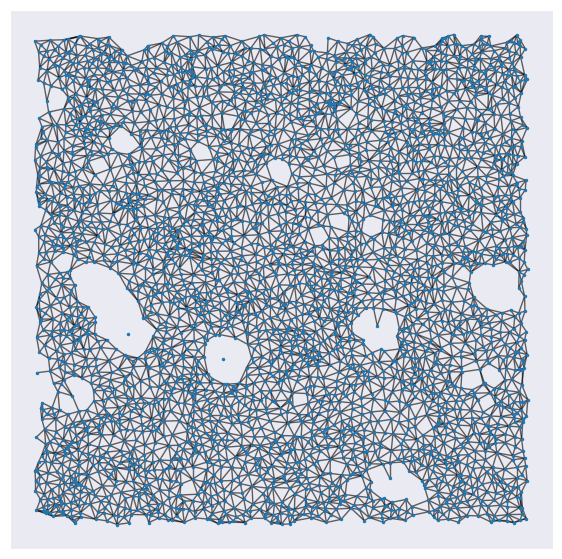

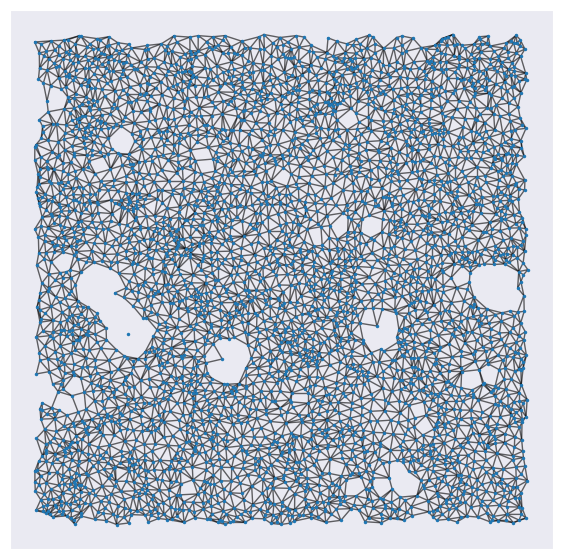

Showing graphs for experiment: E7_rep2


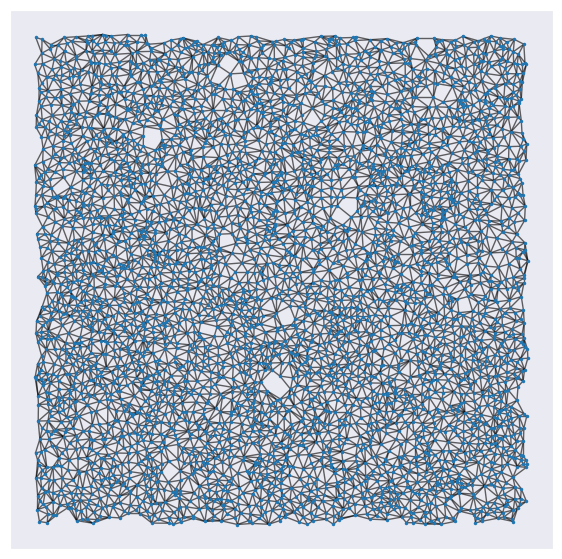

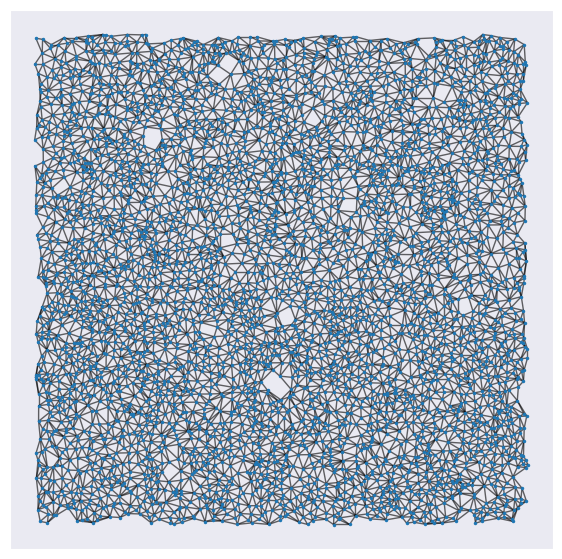

Showing graphs for experiment: D1_rep1


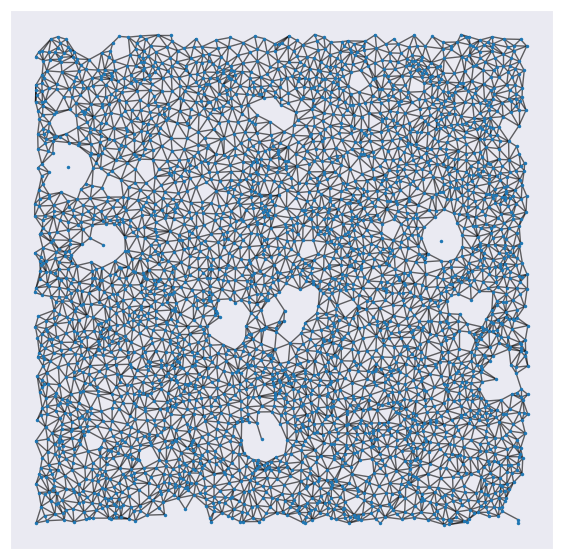

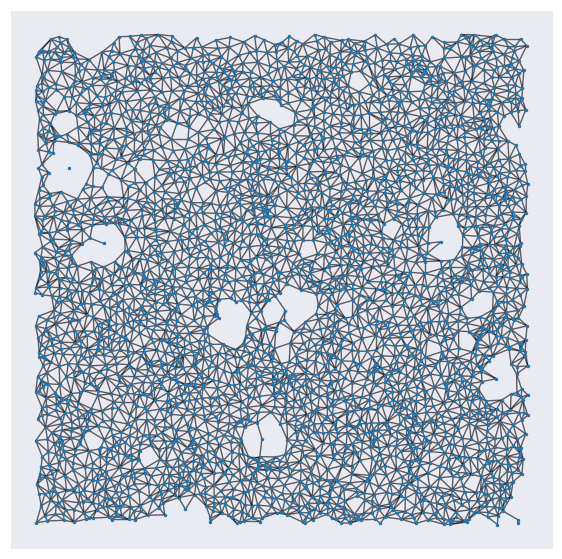

Showing graphs for experiment: G1_rep1


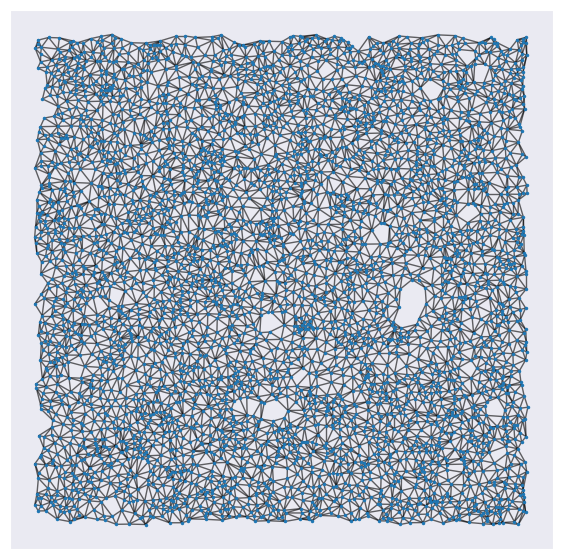

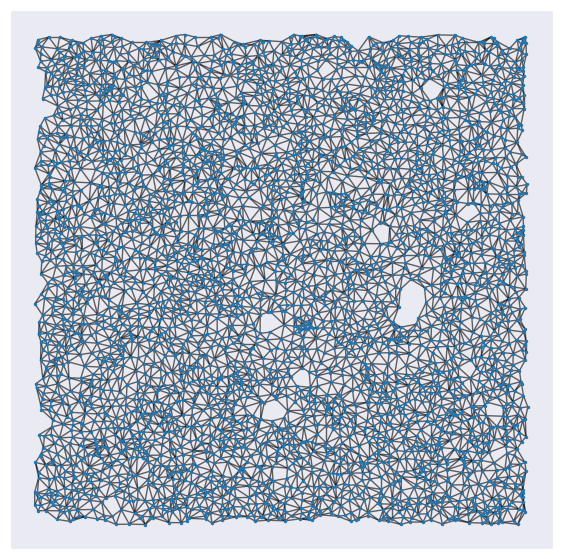

In [48]:
# show graphs in time
for experimentID in key_file["experimentID"].unique():
    print("Showing graphs for experiment:", experimentID)
    t_graphs = graphs[experimentID]

    for t, G_delaunay in enumerate(t_graphs[:2]):  # limit to first 5 time points for visualization

        # visualize the graph for the experiment
        plot_2D(
            G_delaunay,
            alpha_line=0.6,
            scatterpoint_size=2.5,
            legend=True,
            legend_fontsize=14,
            figsize=(7, 7)
        )
        plt.show()

In [49]:
neighbor_lifetimes_tracks_experiments = {}

# iterate over experiments
for experimentID in key_file["experimentID"].unique():
    print("Analyzing experiment with id:", experimentID)
    observation_period_df = observation_period_dfs[experimentID]

    # sample a subset of tracks from tracking file for faster computation
    trackIDs = observation_period_df["TRACK_ID"].unique()

    # iterate over time graphs
    t_graphs = graphs[experimentID]

    # dictionary to hold neighbor lifetimes for all sampled tracks
    neighbor_lifetimes_tracks = {}

    # iterate over sampled tracks
    for track_id in trackIDs:
        neighbor_lifetimes = {}

        # first time point
        t_graphs0 = t_graphs[0]

        if track_id not in t_graphs0.nodes(data="TRACK_ID"):
            print("Track ID %d not present at first time point, skipping..." % track_id)
            continue

        neighbors0 = list(t_graphs0.neighbors(track_id))
        #print("Track ID %d at time 0 has neighbors: %s" % (track_id, neighbors0))

        for neighbor in neighbors0:
            neighbor_lifetimes[neighbor] = 1 # initialize lifetimes at time 0

        # iterate over rest of time points
        for t, G_delaunay in enumerate(t_graphs[1:], start=1):

            # iterate
            node_track = [n for n, d in G_delaunay.nodes(data=True) if d.get("TRACK_ID") == track_id]
            if len(node_track) >1:
                print("Warning: Multiple nodes found for track ID %d at time %d" % (track_id, t))
            elif len(node_track) ==0:
                print("Track ID %d not present at time %d, skipping..." % (track_id, t))
                break

            a = node_track[0]
            neighbors_t = G_delaunay[a]

            # increment lifetime count for each observed neighbor
            for neighbor in neighbors_t:
                if neighbor in neighbor_lifetimes:
                    # increment only if consecutive
                    if neighbor_lifetimes[neighbor] == t:
                        #print("Track ID %d at time 0 had neighbors : %s" % (track_id, neighbors0))
                        #print("Track ID %d at time %d has neighbors: %s" % (track_id, t, neighbors_t))
                        #print("Persisting neighbor: %d at time %d" % (neighbor, t))
                        neighbor_lifetimes[neighbor] += 1
                        #print("Incremented lifetime of neighbor %d to %d" % (neighbor, neighbor_lifetimes[neighbor]))


        neighbor_lifetimes_tracks[track_id] = neighbor_lifetimes
    neighbor_lifetimes_tracks_experiments[experimentID] = neighbor_lifetimes_tracks


Analyzing experiment with id: D2_rep1
Track ID 2036 not present at time 92, skipping...
Track ID 2675 not present at time 75, skipping...
Track ID 3477 not present at time 37, skipping...
Track ID 3476 not present at time 50, skipping...
Track ID 3475 not present at time 20, skipping...
Track ID 3804 not present at time 21, skipping...
Track ID 3474 not present at time 95, skipping...
Track ID 4007 not present at time 19, skipping...
Track ID 2039 not present at time 27, skipping...
Track ID 4082 not present at time 27, skipping...
Track ID 4083 not present at time 19, skipping...
Track ID 3478 not present at time 88, skipping...
Track ID 3920 not present at time 30, skipping...
Track ID 2043 not present at time 59, skipping...
Track ID 3472 not present at time 60, skipping...
Track ID 1609 not present at time 59, skipping...
Track ID 2044 not present at time 37, skipping...
Track ID 2673 not present at time 57, skipping...
Track ID 3785 not present at time 65, skipping...
Track ID 331

Experiment ID: D2_rep1
Sampled track IDs: [ 584 2374 1460 1323  861]
Edge lifetimes for track ID 584: [72, 6, 13, 7, 3, 63]


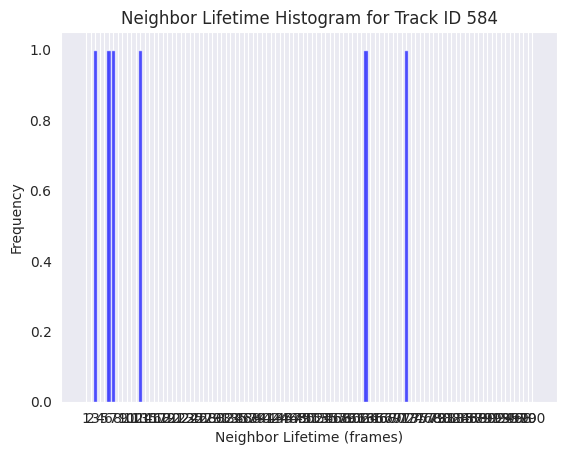

Edge lifetimes for track ID 2374: [22, 49, 2, 30, 11, 25, 11]


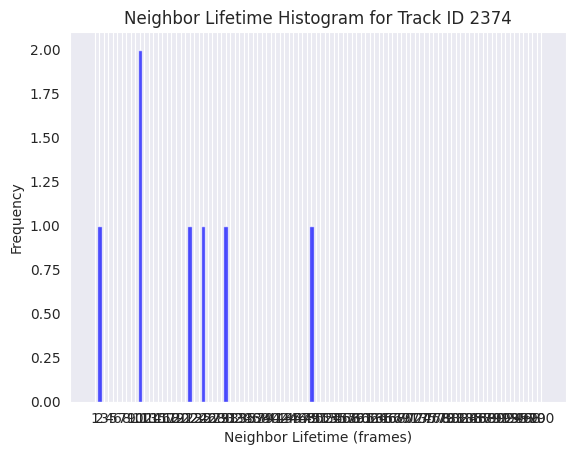

Edge lifetimes for track ID 1460: [2, 9, 26, 22, 6, 21, 2, 4, 11, 22]


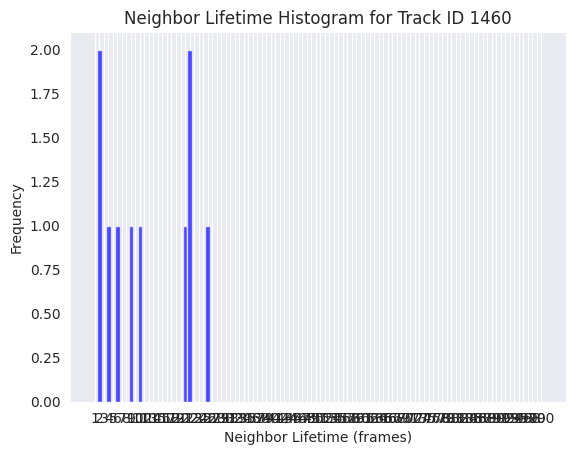

Edge lifetimes for track ID 1323: [36, 5, 25, 19, 20, 7, 19]


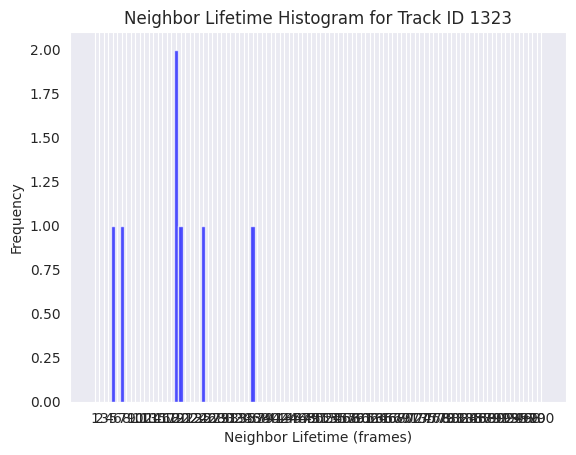

Edge lifetimes for track ID 861: [3, 14, 17, 28, 12, 9]


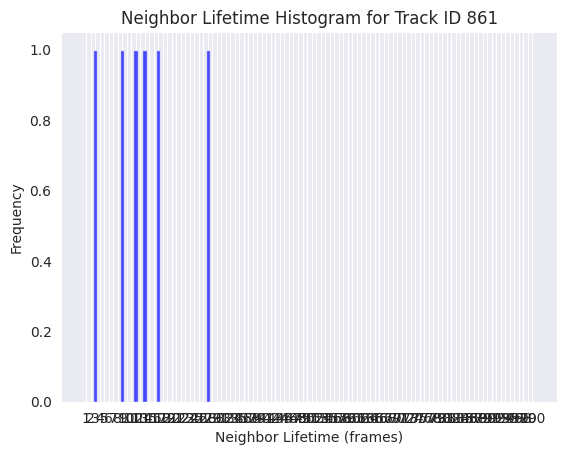

Experiment ID: E7_rep2
Sampled track IDs: [1302 2399  608  803 2926]
Edge lifetimes for track ID 1302: [8, 17, 4, 4, 17, 12, 47]


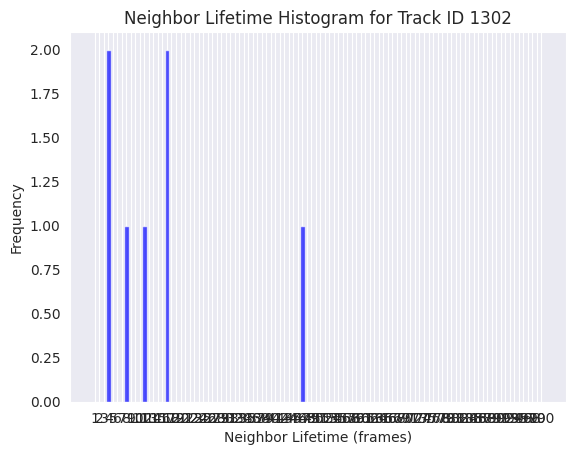

Edge lifetimes for track ID 2399: [19, 26, 39, 35, 58]


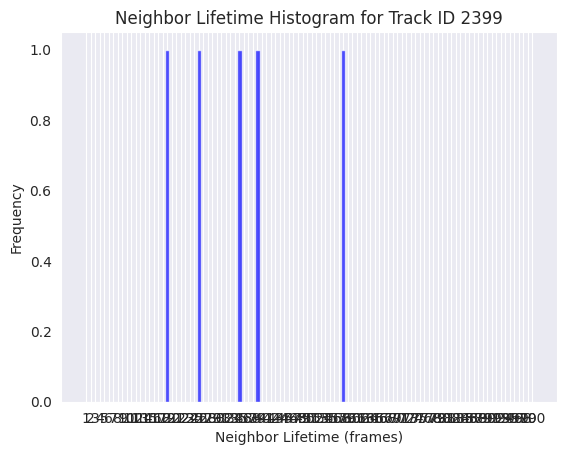

Edge lifetimes for track ID 608: [19, 49, 5, 27]


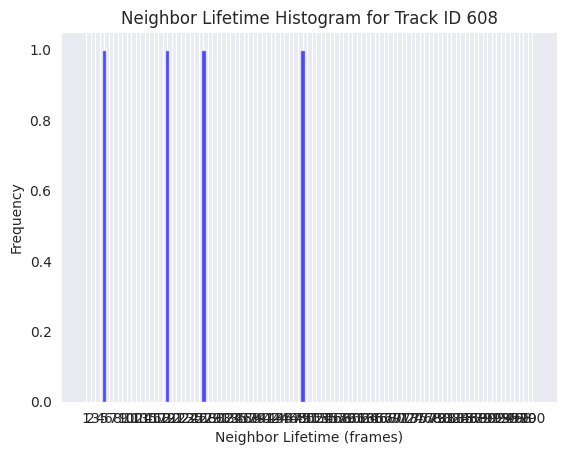

Edge lifetimes for track ID 803: [3, 58, 55, 5, 4, 58, 14, 40]


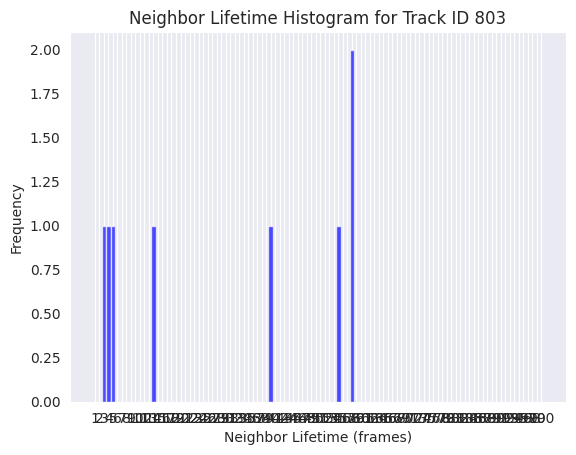

Edge lifetimes for track ID 2926: [74, 23, 10, 42, 28]


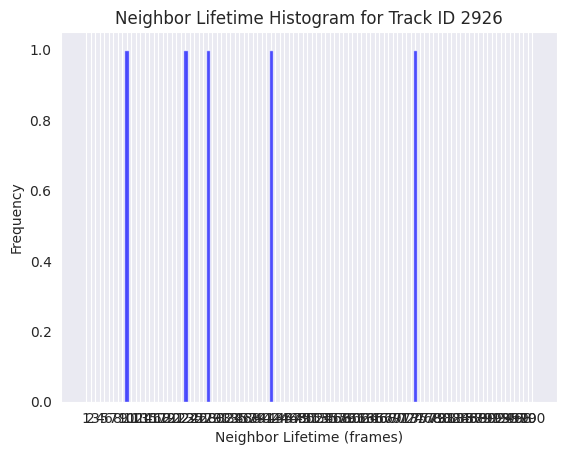

Experiment ID: D1_rep1
Sampled track IDs: [1561  142 2290  791 2830]
Edge lifetimes for track ID 1561: [8, 2, 2, 27, 100, 7]


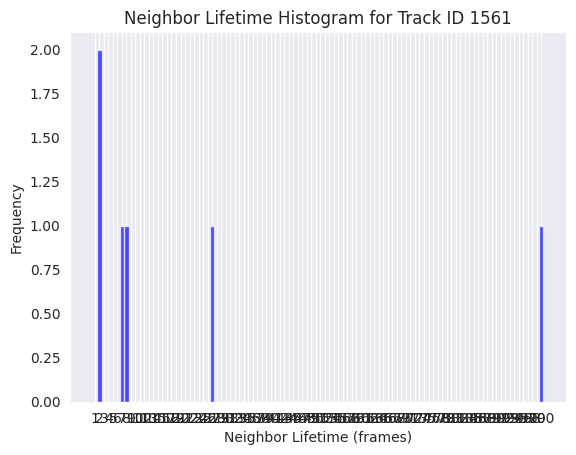

Edge lifetimes for track ID 142: [36, 10, 13, 21, 19, 3]


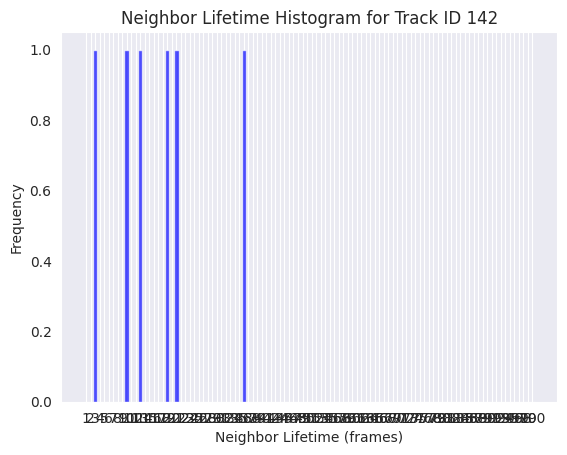

Edge lifetimes for track ID 2290: [24, 1, 8, 2, 6]


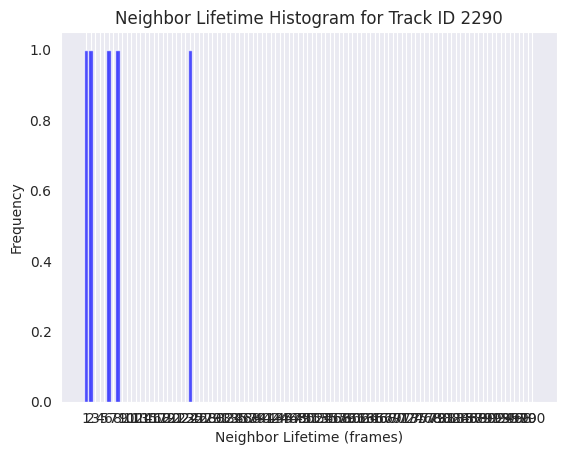

Edge lifetimes for track ID 791: [5, 14, 66, 5, 14]


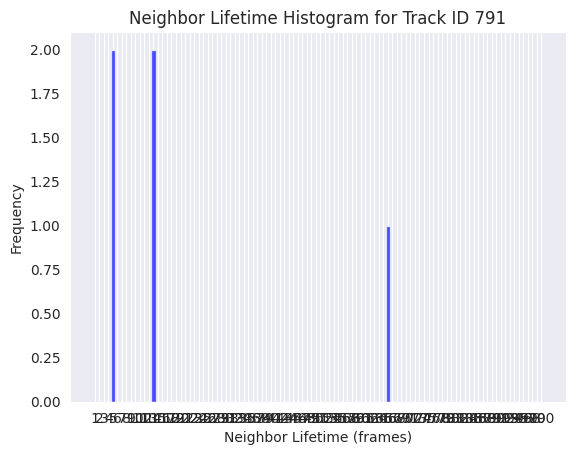

Edge lifetimes for track ID 2830: [7, 19, 2, 19, 16]


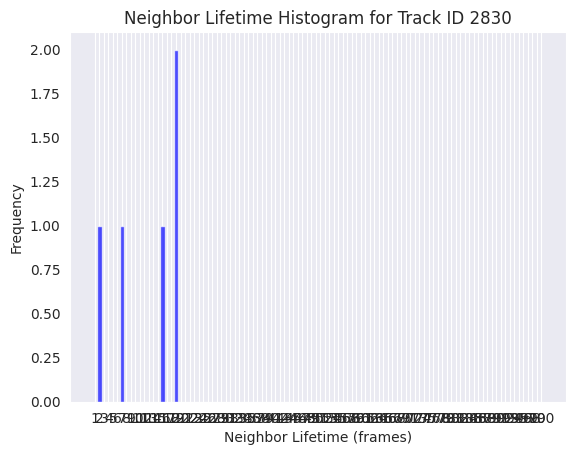

Experiment ID: G1_rep1
Sampled track IDs: [2928  163 3078 3476 1015]
Edge lifetimes for track ID 2928: [22, 56, 39, 1, 34, 11, 9]


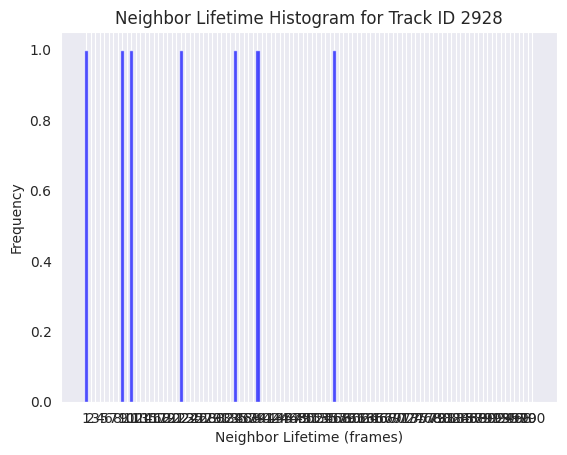

Edge lifetimes for track ID 163: [8, 17, 13, 16, 1]


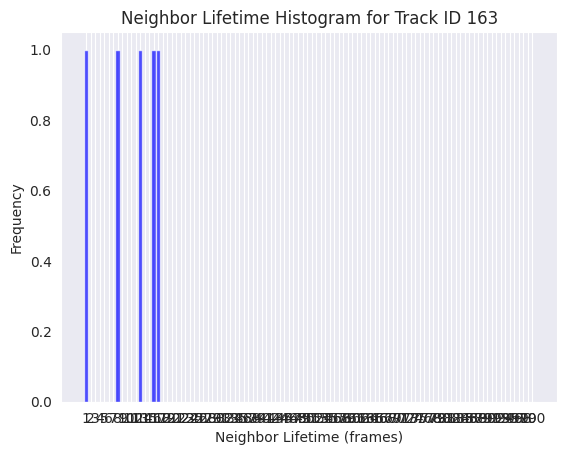

Edge lifetimes for track ID 3078: [34, 30, 37, 51, 2, 4, 4]


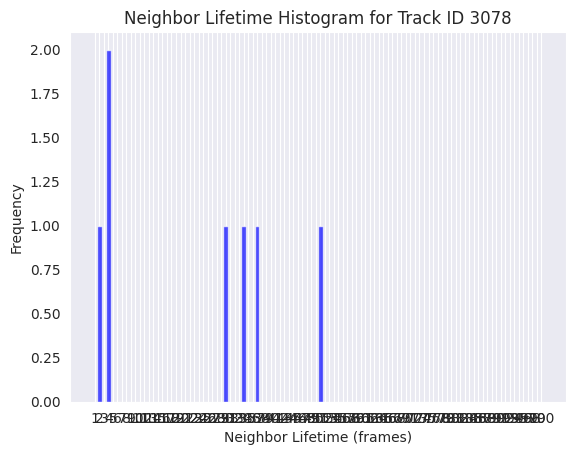

Edge lifetimes for track ID 3476: [24, 5, 1, 10, 44, 13, 19]


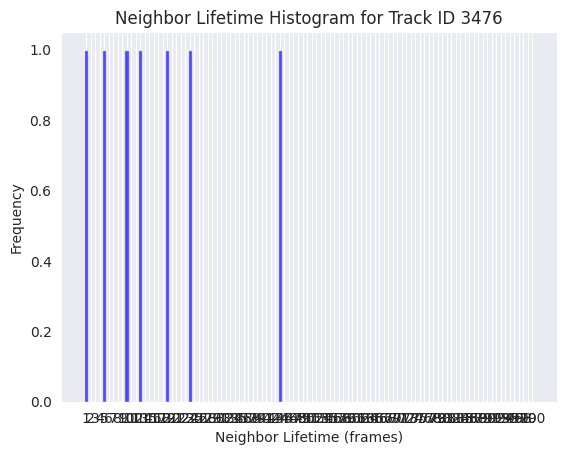

Edge lifetimes for track ID 1015: [41, 56, 26, 8, 7, 41]


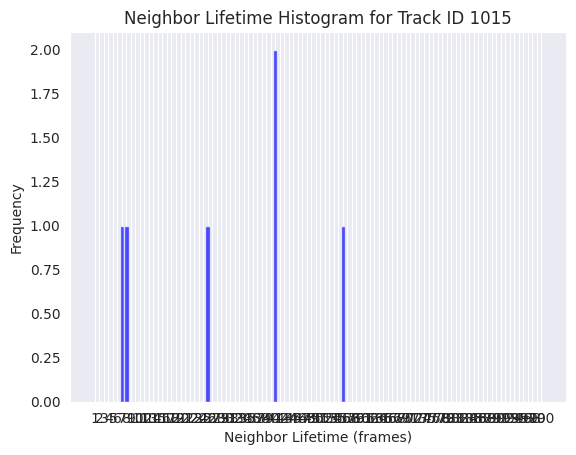

In [50]:
# randomly sample some tracks and plot histograms of neighbor lifetimes
for experimentID in key_file["experimentID"].unique():
    print("Experiment ID:", experimentID)

    neighbor_lifetimes_tracks = neighbor_lifetimes_tracks_experiments[experimentID]

    trackIDs = list(neighbor_lifetimes_tracks.keys())

    if len(trackIDs) > num_subsample:
        sampled_trackIDs = np.random.choice(trackIDs, size=num_subsample, replace=False)
    else:
        sampled_trackIDs = trackIDs

    print("Sampled track IDs:", sampled_trackIDs)

    for track_id in sampled_trackIDs:
        neighbor_lifetimes = neighbor_lifetimes_tracks[track_id]

        lifetimes = list(neighbor_lifetimes.values())
        
        print(f"Edge lifetimes for track ID {track_id}:", lifetimes)

        plt.figure()
        plt.hist(lifetimes, bins=range(1, obs_time_length_frames + 2),
                 align='left', color='blue', alpha=0.7)
        plt.xlabel('Neighbor Lifetime (frames)')
        plt.ylabel('Frequency')
        plt.title(f'Neighbor Lifetime Histogram for Track ID {track_id}')
        plt.xticks(range(1, obs_time_length_frames + 1))
        plt.grid(axis='y')
        plt.show()

Experiment ID: D2_rep1
Mean Neighbor Lifetime: 19.07 frames
Median Neighbor Lifetime: 13.00 frames
Standard Deviation: 19.38 frames
Experiment ID: E7_rep2
Mean Neighbor Lifetime: 24.94 frames
Median Neighbor Lifetime: 17.00 frames
Standard Deviation: 24.11 frames
Experiment ID: D1_rep1
Mean Neighbor Lifetime: 16.64 frames
Median Neighbor Lifetime: 12.00 frames
Standard Deviation: 16.80 frames
Experiment ID: G1_rep1
Mean Neighbor Lifetime: 27.57 frames
Median Neighbor Lifetime: 20.00 frames
Standard Deviation: 25.10 frames


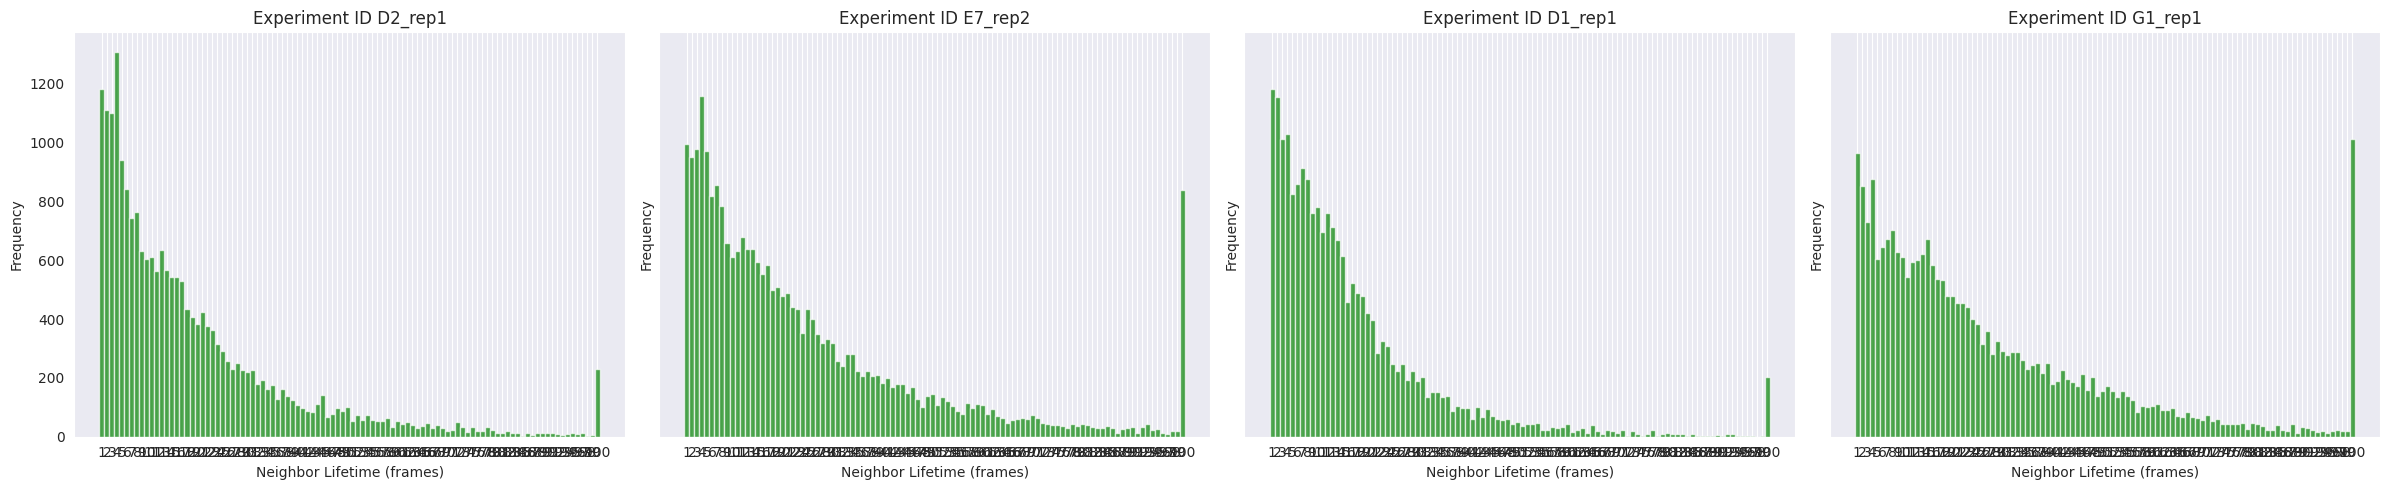

In [51]:
# summary stats of neighbor lifetimes across all tracks
experiment_ids = key_file["experimentID"].unique()

# Prepare a single row of subplots
n_experiments = len(experiment_ids)
fig, axes = plt.subplots(1, n_experiments, figsize=(6 * n_experiments, 5), sharey=True)

if n_experiments == 1:
    axes = [axes]  # ensure axes is iterable even for a single experiment

for ax, experimentID in zip(axes, experiment_ids):
    print("Experiment ID:", experimentID)

    neighbor_lifetimes_tracks = neighbor_lifetimes_tracks_experiments[experimentID]

    all_lifetimes = []
    for track_id, neighbor_lifetimes in neighbor_lifetimes_tracks.items():
        lifetimes = list(neighbor_lifetimes.values())
        all_lifetimes.extend(lifetimes)

    if all_lifetimes:
        mean_lifetime = np.mean(all_lifetimes)
        median_lifetime = np.median(all_lifetimes)
        std_lifetime = np.std(all_lifetimes)

        print(f"Mean Neighbor Lifetime: {mean_lifetime:.2f} frames")
        print(f"Median Neighbor Lifetime: {median_lifetime:.2f} frames")
        print(f"Standard Deviation: {std_lifetime:.2f} frames")

        # plot histogram in its subplot
        ax.hist(all_lifetimes, bins=range(1, obs_time_length_frames + 2),
                align='left', color='green', alpha=0.7)
        ax.set_xlabel('Neighbor Lifetime (frames)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Experiment ID {experimentID}')
        ax.set_xticks(range(1, obs_time_length_frames + 1))
        ax.grid(axis='y')

    else:
        print("No neighbor lifetimes recorded for this experiment.")
        ax.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# neighborhood consistency as a heatmap (tracks × time) to identify locally unstable areas